In [1]:
import pandas as pd

df = pd.read_csv("../data/clinical_trials_raw.csv")

df.head()

,NCTId,Condition,Phase,StudyType,LocationCountry,EnrollmentCount,StartDate
0,NCT00511641,Ovarian Cancer,NaN,OBSERVATIONAL,United States,1342.0,2002-02-12
1,NCT02626754,Renal Cell Carcinoma,PHASE2,INTERVENTIONAL,Taiwan,13.0,2015-08-12
2,NCT04848454,HER2-negative Breast Cancer|Neoadjuvant Therap...,PHASE2,INTERVENTIONAL,China,30.0,2021-11-20
3,NCT03769805,Nonsmall Cell Lung Cancer,NaN,INTERVENTIONAL,China,83.0,2019-06-15
4,NCT05732805,Melanoma|Melanoma (Skin)|Melanoma Stage III|Me...,PHASE3,INTERVENTIONAL,Russia|India|Belarus,270.0,2022-08-02


In [2]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 7 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   NCTId            200 non-null    str    
 1   Condition        200 non-null    str    
 2   Phase            119 non-null    str    
 3   StudyType        200 non-null    str    
 4   LocationCountry  181 non-null    str    
 5   EnrollmentCount  198 non-null    float64
 6   StartDate        199 non-null    str    
dtypes: float64(1), str(6)
memory usage: 11.1 KB


In [3]:
df.isnull().sum()

NCTId               0
Condition           0
Phase              81
StudyType           0
LocationCountry    19
EnrollmentCount     2
StartDate           1
dtype: int64

In [2]:
import pandas as pd

df = pd.read_csv("../data/clinical_trials_raw.csv")
df['Phase'] = df['Phase'].fillna("Not Specified")
df['LocationCountry'] = df['LocationCountry'].fillna("Unknown")
df['EnrollmentCount'] = df['EnrollmentCount'].fillna(df['EnrollmentCount'].median())
df = df.dropna(subset=['StartDate'])

In [3]:
df.info()

<class 'pandas.DataFrame'>
Index: 199 entries, 0 to 199
Data columns (total 7 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   NCTId            199 non-null    str    
 1   Condition        199 non-null    str    
 2   Phase            199 non-null    str    
 3   StudyType        199 non-null    str    
 4   LocationCountry  199 non-null    str    
 5   EnrollmentCount  199 non-null    float64
 6   StartDate        199 non-null    str    
dtypes: float64(1), str(6)
memory usage: 12.4 KB


In [4]:
df.isnull().sum()

NCTId              0
Condition          0
Phase              0
StudyType          0
LocationCountry    0
EnrollmentCount    0
StartDate          0
dtype: int64

### Handling Missing Values

- Phase: Missing values replaced with "Not Specified"
- LocationCountry: Missing values replaced with "Unknown"
- EnrollmentCount: Filled with median to reduce effect of outliers
- StartDate: Rows removed (only 1 missing value)

## Exploratory Data Analysis (EDA)

In [5]:
top_conditions = df['Condition'].value_counts().head(10)

top_conditions

Condition
Breast Cancer                   7
Prostate Cancer                 3
Ovarian Cancer                  2
Acute Myeloid Leukemia          2
Pancreatic Cancer               2
Hepatocellular Carcinoma        2
Advanced Solid Tumors           2
Colorectal Cancer Metastatic    2
NSCLC                           2
Non-small Cell Lung Cancer      2
Name: count, dtype: int64

In [15]:
mapping = {
    "NSCLC": "Non-small Cell Lung Cancer",
    "Non-small Cell Lung Cancer": "Non Small Cell Lung Cancer",
    "Non Small Cell Lung Cancer": "Non Small Cell Lung Cancer"
}

df["Condition"] = df["Condition"].replace(mapping)


In [16]:
top_conditions = df['Condition'].value_counts().head(10)

top_conditions

Condition
Breast Cancer                   7
Non Small Cell Lung Cancer      6
Prostate Cancer                 3
Ovarian Cancer                  2
Acute Myeloid Leukemia          2
Pancreatic Cancer               2
Hepatocellular Carcinoma        2
Advanced Solid Tumors           2
Colorectal Cancer Metastatic    2
Metastatic Colorectal Cancer    2
Name: count, dtype: int64

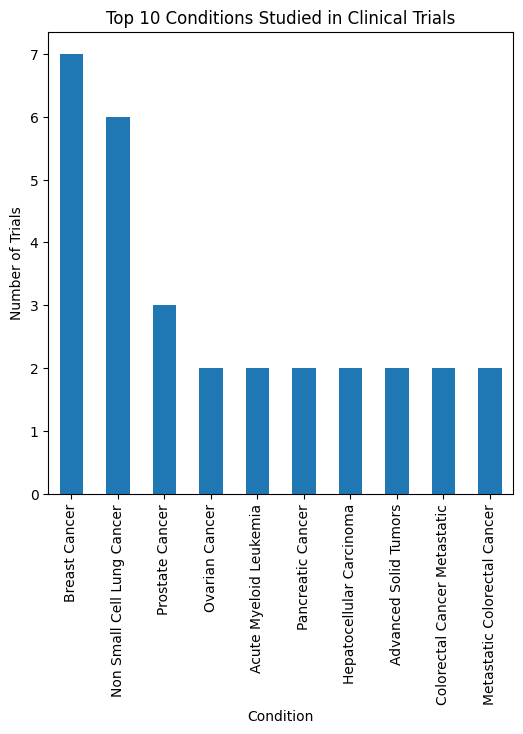

In [17]:
plt.figure(figsize=(6, 6))

top_conditions.plot(kind='bar')

plt.title("Top 10 Conditions Studied in Clinical Trials")
plt.xlabel("Condition")
plt.ylabel("Number of Trials")
plt.xticks(rotation=90)

plt.show()

### Distribution of Clinical Trial Phases

In [18]:
phase_counts = df['Phase'].value_counts()

phase_counts

Phase
Not Specified    81
PHASE2           45
PHASE1           30
PHASE3           20
PHASE1|PHASE2    13
PHASE4            9
EARLY_PHASE1      1
Name: count, dtype: int64

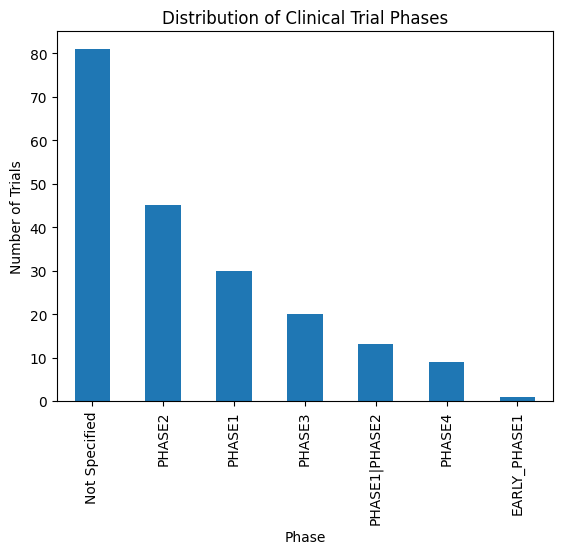

In [19]:
phase_counts.plot(kind='bar')

plt.title("Distribution of Clinical Trial Phases")
plt.xlabel("Phase")
plt.ylabel("Number of Trials")

plt.show()